# Fashion Products EDA

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df = pd.read_csv("../../fashion_items/styles.csv", on_bad_lines="skip")
df


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt
...,...,...,...,...,...,...,...,...,...,...
44419,17036,Men,Footwear,Shoes,Casual Shoes,White,Summer,2013.0,Casual,Gas Men Caddy Casual Shoe
44420,6461,Men,Footwear,Flip Flops,Flip Flops,Red,Summer,2011.0,Casual,Lotto Men's Soccer Track Flip Flop
44421,18842,Men,Apparel,Topwear,Tshirts,Blue,Fall,2011.0,Casual,Puma Men Graphic Stellar Blue Tshirt
44422,46694,Women,Personal Care,Fragrance,Perfume and Body Mist,Blue,Spring,2017.0,Casual,Rasasi Women Blue Lady Perfume


## 2. Dataset Overview

In [7]:
print("Shape:", df.shape, "\n")
print("Columns:\n", df.columns, "\n")
print("Info:")
df.info()
print("\nSummary:\n")
print(df.describe(include="all"))


Shape: (44424, 10) 

Columns:
 Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='str') 

Info:
<class 'pandas.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  str    
 2   masterCategory      44424 non-null  str    
 3   subCategory         44424 non-null  str    
 4   articleType         44424 non-null  str    
 5   baseColour          44409 non-null  str    
 6   season              44403 non-null  str    
 7   year                44423 non-null  float64
 8   usage               44107 non-null  str    
 9   productDisplayName  44417 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 3.4 MB

Summary:

                  id gender masterCategory su

## 3. Data Quality

In [8]:
# Missing values — count and percentage for columns that have any
na_counts = df.isna().sum()
na_percent = (na_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": na_counts,
    "Missing %": na_percent.round(2)
}).query("`Missing Count` > 0")

missing_summary


,Missing Count,Missing %
baseColour,15,0.03
season,21,0.05
year,1,0.00
usage,317,0.71
productDisplayName,7,0.02


## 4. Feature Engineering

In [ ]:
COLOR_GROUP_MAP = {
    # Neutral
    "Black": "Neutral",
    "White": "Neutral",
    "Grey": "Neutral",
    "Gray": "Neutral", 
    "Beige": "Neutral",
    "Cream": "Neutral",
    "Off White": "Neutral",

    # Cool
    "Blue": "Cool",
    "Navy Blue": "Cool",
    "Teal": "Cool",
    "Turquoise Blue": "Cool",
    "Green": "Cool",
    "Olive": "Cool",
    "Sea Green": "Cool",
    "Lime Green": "Cool",
    "Purple": "Cool",
    "Lavender": "Cool",
    "Indigo": "Cool",
    "Violet": "Cool",

    # Warm
    "Brown": "Warm",
    "Red": "Warm",
    "Maroon": "Warm",
    "Burgundy": "Warm",
    "Orange": "Warm",
    "Peach": "Warm",
    "Coral": "Warm",
    "Yellow": "Warm",
    "Mustard": "Warm",
    "Rust": "Warm",
    "Pink": "Warm",
    "Magenta": "Warm",
    "Khaki": "Warm",
    "Tan": "Warm",

    # Metallic
    "Silver": "Metallic",
    "Gold": "Metallic",
    "Bronze": "Metallic",
    "Copper": "Metallic",
}

# Add colorGroup column for misilaneous values, called "Other"
df["colorGroup"] = df["baseColour"].map(COLOR_GROUP_MAP).fillna("Other")


print(df[["baseColour", "colorGroup"]].head(10))
print("\ncolorGroup counts:\n", df["colorGroup"].value_counts())


  baseColour colorGroup
0  Navy Blue       Cool
1       Blue       Cool
2     Silver   Metallic
3      Black    Neutral
4       Grey    Neutral
5       Grey    Neutral
6      Green       Cool
7     Purple       Cool
8  Navy Blue       Cool
9      Black    Neutral

colorGroup counts:
 colorGroup
Neutral     19328
Cool        11251
Warm        10483
Metallic     1899
Other        1463
Name: count, dtype: int64


## 5. Univariate Distributions

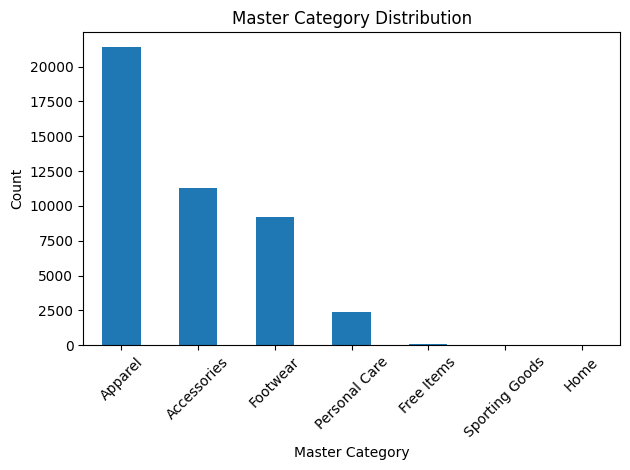

In [12]:
plt.figure()
df["masterCategory"].value_counts().plot(kind="bar")
plt.title("Master Category Distribution")
plt.xlabel("Master Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


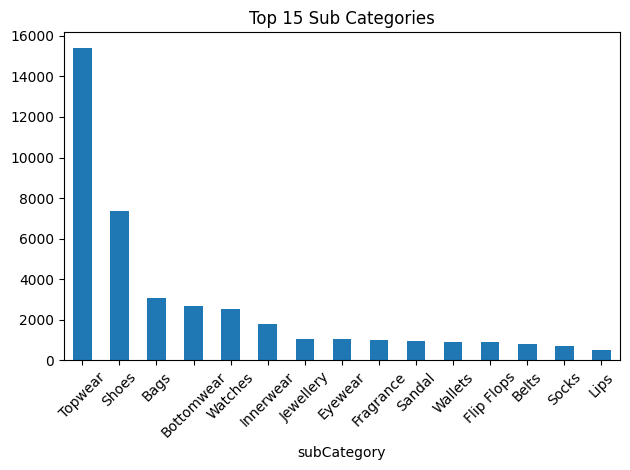

In [13]:
plt.figure()
df["subCategory"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Sub Categories")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure()
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure()
df["baseColour"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Base Colours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure()
df["season"].value_counts().plot(kind="bar")
plt.title("Season Distribution")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure()
df["usage"].value_counts().plot(kind="bar")
plt.title("Usage Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure()
df["year"].dropna().hist()
plt.title("Year Distribution")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 6. Bivariate Analysis

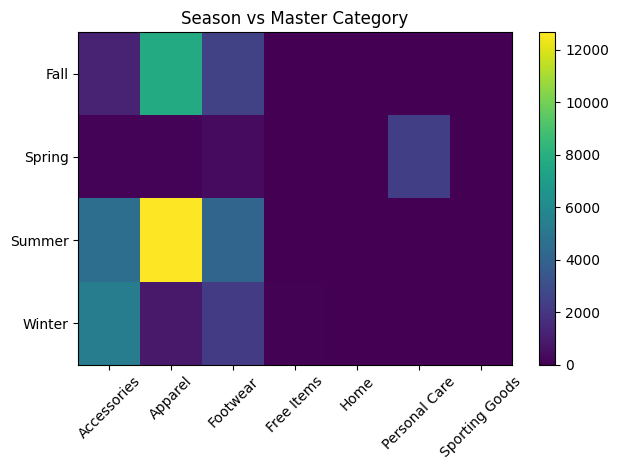

In [14]:
season_master = pd.crosstab(df["season"], df["masterCategory"])

plt.figure()
plt.imshow(season_master, aspect="auto")
plt.colorbar()
plt.xticks(range(len(season_master.columns)), season_master.columns, rotation=45)
plt.yticks(range(len(season_master.index)), season_master.index)
plt.title("Season vs Master Category")
plt.tight_layout()
plt.show()


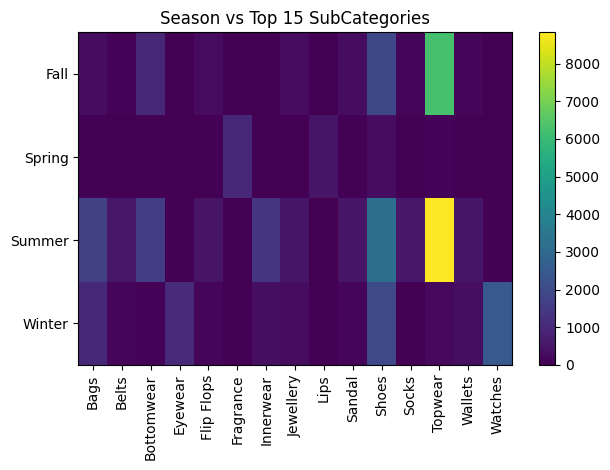

In [16]:
top_sub = df["subCategory"].value_counts().head(15).index
filtered_df = df[df["subCategory"].isin(top_sub)]

season_sub = pd.crosstab(filtered_df["season"], filtered_df["subCategory"])

plt.figure()
plt.imshow(season_sub, aspect="auto")
plt.colorbar()
plt.xticks(range(len(season_sub.columns)), season_sub.columns, rotation=90)
plt.yticks(range(len(season_sub.index)), season_sub.index)
plt.title("Season vs Top 15 SubCategories")
plt.tight_layout()
plt.show()


## 7. Key Observations

Are certain categories seasonal?
A: Summer / Fall items dominate the dataset, there is a clear imbalance between summer / fall and spring / winter fashion items.

Are socks mostly winter?
There are only 698 items for socks compared to 8000 + topwear, so we need to normalize... !

Are T-shirts mostly summer?
T-shirts are mostly summer in this dataset.

Are accessories season-independent?


In [ ]:
# Focus only socks
socks = df[df["subCategory"] == "Socks"]

print("Number of socks:", len(socks))

# Show season distribution INCLUDING NaN
print(socks["season"].value_counts())


Number of socks: 698
season
Summer    569
Fall      114
Winter     12
Spring      3
Name: count, dtype: int64
